#        Analyse Exploratoire des Données (EDA) — Obesity Dataset

L’objectif de ce notebook est de réaliser une analyse exploratoire des données (Exploratory Data Analysis - EDA) sur le dataset d’estimation du niveau d’obésité basé sur les habitudes alimentaires et les conditions physiques des individus.
Cette étape est essentielle dans un projet de Machine Learning, car elle permet de mieux comprendre la structure des données, d’identifier d’éventuels problèmes dans le dataset et de préparer les données pour les étapes de modélisation.

L’analyse exploratoire vise notamment à :

- Comprendre la structure générale du dataset (types de variables, dimensions, etc.)    
- Identifier la présence éventuelle de valeurs manquantes
- Vérifier la présence de doublons
- Analyser la distribution des classes d’obésité
- Étudier les corrélations entre les variables
- Visualiser la distribution des variables numériques
- Détecter la présence de valeurs aberrantes (outliers)

En plus de cette analyse exploratoire, certaines opérations de nettoyage et de transformation des données seront également réalisées, notamment :

- la suppression des doublons
- l’encodage des variables catégorielles
- la conversion des variables en format numérique pour le Machine Learning
- l’optimisation de l’utilisation de la mémoire

Enfin, une version nettoyée du dataset sera sauvegardée afin d’être utilisée dans les étapes suivantes du projet, notamment l’entraînement et l’évaluation des modèles de Machine Learning.


## Importation des bibliothèques
Nous importons les bibliothèques nécessaires pour la manipulation des données
et la visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## Chargement du dataset

Le dataset est chargé à partir d’un fichier CSV contenant les informations
liées aux habitudes alimentaires, au mode de vie et au niveau d’obésité.

Après le chargement des données, le dataset est stocké dans un DataFrame Pandas afin de faciliter son analyse.

In [3]:
df = pd.read_csv("../data/ObesityDataSet_raw_and_data_sinthetic.csv")

df


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [4]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Les 5 premières lignes du dataset sont affichées.
Cela permet d’observer rapidement la structure des données et les variables présentes dans le dataset.

## Aperçu général du dataset

Cette étape permet d’obtenir une vue générale du dataset.

Nous examinons la taille du dataset, les types de variables et les statistiques
descriptives.

In [8]:
df.shape

(2111, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

La fonction`df.info()`permet d’obtenir un résumé général de la structure du dataset.

Elle fournit plusieurs informations importantes, notamment :

- le nombre total de lignes dans le dataset
- les noms des colonnes
- le type de données de chaque variable (int, float, object, category, etc.)
- le nombre de valeurs non nulles pour chaque colonne
- la consommation mémoire du dataframe

Cette fonction est très utile pour comprendre rapidement la structure des données et vérifier si certaines variables contiennent des valeurs manquantes ou des types de données incorrects.

## Vue d’ensemble du dataset

Avant d’effectuer des opérations de nettoyage ou de transformation, il est essentiel d’explorer la structure générale du jeu de données.  
Cette étape permet d’obtenir une première compréhension des variables, de leurs types ainsi que des caractéristiques globales des données.

Nous allons donc calculer quelques statistiques descriptives afin de résumer les variables numériques et repérer d’éventuelles anomalies.

In [10]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## Analyse des valeurs manquantes
La présence de valeurs manquantes peut affecter la qualité de l’analyse et les performances des modèles de Machine Learning.
              
Dans cette étape, nous vérifions si certaines variables contiennent des valeurs manquantes.
 Si des valeurs manquantes sont détectées, elles devront être traitées par des techniques appropriées telles que la suppression ou l’imputation.

In [11]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

La fonction `df.isnull().sum()` permet de vérifier la présence de valeurs manquantes dans le dataset.Elle calcule le nombre total de valeurs nulles pour chaque colonne du dataframe.

Les résultats montrent que toutes les colonnes du dataset contiennent 0 valeurs manquantes.Cela signifie que le dataset est complet et ne nécessite pas de traitement spécifique pour gérer des valeurs manquantes.

Par conséquent, aucune technique d’imputation ou de suppression de données n’est nécessaire à cette étape, et l’analyse peut se poursuivre avec les données disponibles.

## Vérification des lignes dupliquées

Les lignes dupliquées peuvent apparaître lors de la collecte ou de la fusion de données provenant de différentes sources.  
Ces duplications peuvent biaiser les analyses statistiques ainsi que les modèles de machine learning.

Dans cette étape, nous vérifions si le dataset contient des observations dupliquées.

In [12]:
df.duplicated().sum()

24

## Distribution des classes et déséquilibre des classes
Dans cette section, nous analysons la distribution des différentes classes d’obésité présentes dans le dataset.

Cette analyse permet de vérifier si le dataset présente un déséquilibre de classes (class imbalance).
Un déséquilibre de classes peut affecter les performances des modèles de machine learning, car certaines classes peuvent être sous-représentées.

L’objectif est donc d’observer le nombre d’exemples pour chaque niveau d’obésité et de déterminer si des techniques spécifiques (oversampling, undersampling ou pondération des classes) sont nécessaires.


In [15]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

In [16]:
df['NObeyesdad'].value_counts(normalize=True) * 100

NObeyesdad
Obesity_Type_I         16.818400
Obesity_Type_III       15.524677
Obesity_Type_II        14.230954
Overweight_Level_II    13.895544
Normal_Weight          13.512218
Overweight_Level_I     13.224724
Insufficient_Weight    12.793483
Name: proportion, dtype: float64

Les résultats montrent que les différentes classes d’obésité sont relativement équilibrées, chaque classe représentant environ 12 % à 15 % du dataset.

Par conséquent, le dataset ne présente pas de déséquilibre de classes significatif.
Il n’est donc pas nécessaire d’appliquer des techniques de rééquilibrage telles que l’oversampling ou l’undersampling.

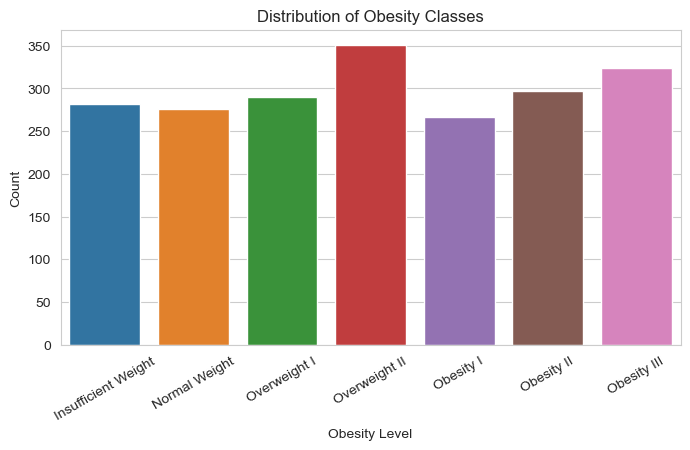

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["NObeyesdad"])

labels = [
    "Insufficient Weight",
    "Normal Weight",
    "Overweight I",
    "Overweight II",
    "Obesity I",
    "Obesity II",
    "Obesity III"
]

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=30)

plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.subplots_adjust(bottom=0.25)

plt.show()


## Suppression des doublons

Si des doublons sont détectés dans le dataset, il est nécessaire de les supprimer afin que chaque observation représente un individu unique.

La suppression des doublons permet de préserver l’intégrité du jeu de données et d’éviter qu’une observation soit surreprésentée dans l’analyse.

Dans notre cas, 24 lignes dupliquées ont été identifiées dans le dataset. Ces doublons seront donc supprimés afin d’assurer la qualité et la fiabilité des données utilisées dans les étapes suivantes du projet.

In [13]:
df = df.drop_duplicates()
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


## Réinitialisation de l’index

Après la suppression de certaines lignes (par exemple lors de la suppression des doublons), l’index du dataframe peut contenir des discontinuités ou des valeurs manquantes dans la numérotation.

La fonction `reset_index()`permet de réinitialiser l’index afin d’obtenir une numérotation propre et continue des observations.

L’option `drop=True` est utilisée pour éviter que l’ancien index soit ajouté comme une nouvelle colonne dans le dataframe.

Cette étape permet de maintenir une structure de données cohérente avant de poursuivre l’analyse.

In [14]:
df = df.reset_index(drop=True)
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2083,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2084,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2085,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


## Identification et conversion des variables catégorielles

Dans cette étape, nous identifions les colonnes contenant des variables catégorielles dans le dataset.

Les variables de type `object` correspondent généralement à des données textuelles représentant des catégories (par exemple : genre, habitudes alimentaires, type de transport, etc.). Nous sélectionnons donc toutes les colonnes de ce type.

Ensuite, nous convertissons ces colonnes vers le type `category`. Ce type est plus adapté pour représenter des variables catégorielles car il permet :
- une meilleure organisation des catégories,
- une réduction de l'utilisation de la mémoire,
- une préparation plus efficace pour certaines analyses ou transformations ultérieures.

Enfin, nous utilisons `df.info()` pour vérifier que les colonnes ont bien été converties et pour observer la structure actuelle du dataframe (types des variables, nombre de valeurs non nulles, etc.).

In [18]:
col_category = df.select_dtypes(include=['object']).columns

df[col_category ] = df[col_category ].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2087 non-null   category
 1   Age                             2087 non-null   float64 
 2   Height                          2087 non-null   float64 
 3   Weight                          2087 non-null   float64 
 4   family_history_with_overweight  2087 non-null   category
 5   FAVC                            2087 non-null   category
 6   FCVC                            2087 non-null   float64 
 7   NCP                             2087 non-null   float64 
 8   CAEC                            2087 non-null   category
 9   SMOKE                           2087 non-null   category
 10  CH2O                            2087 non-null   float64 
 11  SCC                             2087 non-null   category
 12  FAF                 

## Encodage des variables binaires

Certaines variables catégorielles possèdent des valeurs binaires comme "yes" et "no".  
Pour permettre leur utilisation dans des traitements numériques ou des modèles de machine learning, ces valeurs doivent être converties en valeurs numériques.

Dans cette étape, nous effectuons la transformation suivante :

- "yes" → 1  
- "no" → 0

In [19]:
yes_no_cols = ['family_history_with_overweight','FAVC','SMOKE','SCC']

for col in yes_no_cols:
    df[col] = df[col].str.lower()
    df[col] = df[col].map({'yes':1,'no':0})
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,1,0,2.0,3.0,Sometimes,0,2.000000,0,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,1,0,3.0,3.0,Sometimes,1,3.000000,1,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,1,0,2.0,3.0,Sometimes,0,2.000000,0,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,0,0,3.0,3.0,Sometimes,0,2.000000,0,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,0,0,2.0,1.0,Sometimes,0,2.000000,0,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Female,20.976842,1.710730,131.408528,1,1,3.0,3.0,Sometimes,0,1.728139,0,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2083,Female,21.982942,1.748584,133.742943,1,1,3.0,3.0,Sometimes,0,2.005130,0,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2084,Female,22.524036,1.752206,133.689352,1,1,3.0,3.0,Sometimes,0,2.054193,0,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2085,Female,24.361936,1.739450,133.346641,1,1,3.0,3.0,Sometimes,0,2.852339,0,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [20]:
df['NObeyesdad'] = df['NObeyesdad'].astype('category').cat.codes
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})
df['CAEC'] = df['CAEC'].apply(lambda x: 3 if x == 'Always' else (2 if x == 'Frequently' else (1 if x == 'Sometimes' else 0)))
df['CALC'] = df['CALC'].apply(lambda x: 3 if x == 'Always' else (2 if x == 'Frequently' else (1 if x == 'Sometimes' else 0)))
df['MTRANS'] = df['MTRANS'].map({'Automobile':0, 'Bike':1, 'Motorbike':2, 'Public_Transportation':3, 'Walking':4})
df  

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,1,21.000000,1.620000,64.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,3,1
1,1,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,3,1
2,0,23.000000,1.800000,77.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,3,1
3,0,27.000000,1.800000,87.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,4,5
4,0,22.000000,1.780000,89.800000,0,0,2.0,1.0,1,0,2.000000,0,0.000000,0.000000,1,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,1,20.976842,1.710730,131.408528,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,3,4
2083,1,21.982942,1.748584,133.742943,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,3,4
2084,1,22.524036,1.752206,133.689352,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,3,4
2085,1,24.361936,1.739450,133.346641,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,3,4


Dans cette étape, certaines variables catégorielles du dataset sont converties en valeurs numériques afin de pouvoir être utilisées par les modèles de Machine Learning. En effet, la plupart des algorithmes de Machine Learning ne peuvent pas traiter directement des données textuelles.

Plusieurs techniques d’encodage sont appliquées selon la nature des variables :

La variable cible "NObeyesdad" est convertie en codes numériques à l’aide de la méthode astype('category').cat.codes, ce qui attribue un identifiant numérique à chaque niveau d’obésité.

La variable "Gender" est transformée en valeurs binaires (Male = 0, Female = 1).

Les variables "CAEC (consommation d’aliments entre les repas)" et "CALC (consommation d’alcool)" sont des variables ordinales. Elles sont donc converties en valeurs numériques représentant l’intensité ou la fréquence :

- 0 : No
- 1 : Sometimes
- 2 : Frequently
- 3 : Always

La variable "MTRANS", qui représente le moyen de transport utilisé, est également encodée en valeurs numériques correspondant à chaque catégorie.

Cette transformation permet de rendre les variables compatibles avec les modèles de Machine Learning qui seront utilisés dans les étapes suivantes du projet.

Si tu veux, je peux aussi te donner une petite amélioration de ce code (plus propre et plus professionnelle) que les data scientists utilisent souvent à la place de lambda pour ces colonnes.

## Analyse des corrélations :


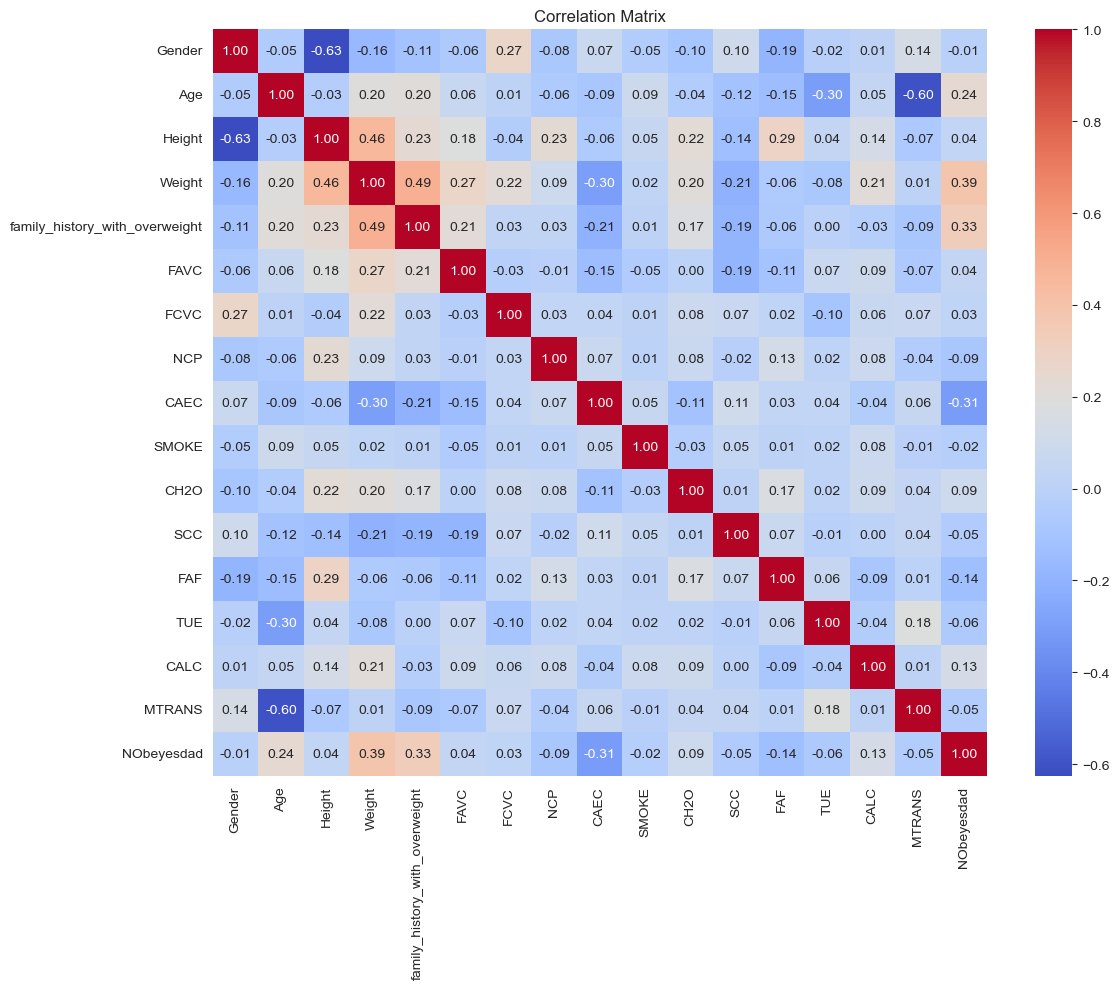

In [21]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Afin de mieux comprendre les relations entre les différentes variables du jeu de données, une **matrice de corrélation** a été calculée puis visualisée sous forme de **heatmap**. La corrélation mesure la force et la direction de la relation linéaire entre deux variables. Les valeurs varient entre **-1 et 1** : une valeur positive indique que les deux variables évoluent dans le même sens, une valeur négative indique qu'elles évoluent en sens opposé, tandis qu'une valeur proche de **0** signifie qu'il existe peu ou pas de relation linéaire.

La heatmap permet de représenter ces corrélations de manière visuelle et intuitive. Les couleurs **chaudes (rouge)** représentent des corrélations positives, les couleurs **froides (bleu)** indiquent des corrélations négatives, tandis que les couleurs proches du neutre correspondent à des corrélations faibles.

L'analyse de la matrice de corrélation met en évidence plusieurs relations intéressantes entre les variables :

- **Height et Weight (0.46)** présentent une corrélation positive modérée. Cela est attendu car les personnes plus grandes ont généralement un poids plus élevé.

- **Weight et family_history_with_overweight (0.49)** montrent également une corrélation positive modérée, ce qui suggère que les individus ayant des antécédents familiaux de surpoids ont tendance à présenter un poids plus élevé.

- La variable **NObeyesdad** (niveau d'obésité) est modérément corrélée avec **Weight (0.39)** et **family_history_with_overweight (0.33)**. Ces résultats indiquent que le poids et les facteurs familiaux jouent un rôle important dans la classification du niveau d'obésité.

- Une corrélation négative modérée est observée entre **CAEC (-0.31)** et **NObeyesdad**, ce qui peut indiquer une relation entre certaines habitudes alimentaires et les niveaux d'obésité.

- La corrélation négative relativement forte entre **Gender et Height (-0.63)** reflète probablement la manière dont la variable genre a été encodée dans le jeu de données et les différences moyennes de taille entre les groupes.

Globalement, la majorité des variables présentent des **corrélations faibles**, ce qui indique qu'il n'existe pas de relation linéaire forte entre la plupart des caractéristiques. Cependant, certaines variables comme **Weight** et **family_history_with_overweight** montrent une relation plus marquée avec le niveau d'obésité, ce qui suggère qu'elles pourraient être des variables importantes pour la modélisation prédictive dans les étapes suivantes du projet.


## Distribution des variables numériques

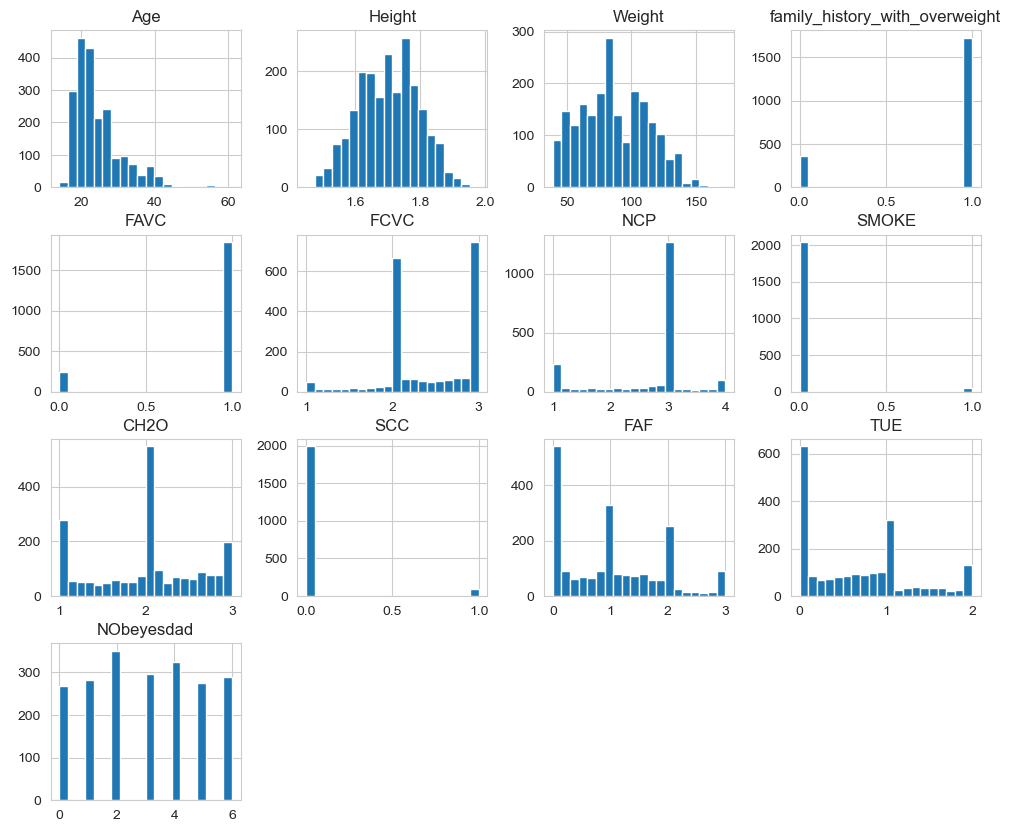

In [22]:
df.hist(figsize=(12,10), bins=20)
plt.show()


les histogrammes permettent d’observer la distribution des variables numériques du dataset. Ils montrent comment les valeurs sont réparties et permettent d’identifier la forme générale de la distribution de chaque variable.

Cette visualisation aide à :

- comprendre la répartition des données
- identifier d’éventuelles asymétries dans la distribution
- détecter la présence possible de valeurs extrêmes (outliers)
- observer la concentration des valeurs autour de certaines zones.

L’analyse de la distribution des variables numériques constitue une étape importante de l’analyse exploratoire des données (EDA), car elle permet de mieux comprendre les caractéristiques des variables avant l’étape de modélisation.

## Détection des valeurs aberrantes (Outliers)
La détection des valeurs aberrantes permet d’identifier les observations dont les valeurs sont très différentes du reste des données. Ces valeurs peuvent provenir d’erreurs de mesure, d’erreurs de saisie ou représenter des cas particuliers.

Dans cette étape, des boxplots sont utilisés pour visualiser la distribution des variables numériques et détecter les éventuelles valeurs extrêmes. L’identification des outliers est importante car ils peuvent influencer les analyses statistiques et les performances des modèles de machine learning.

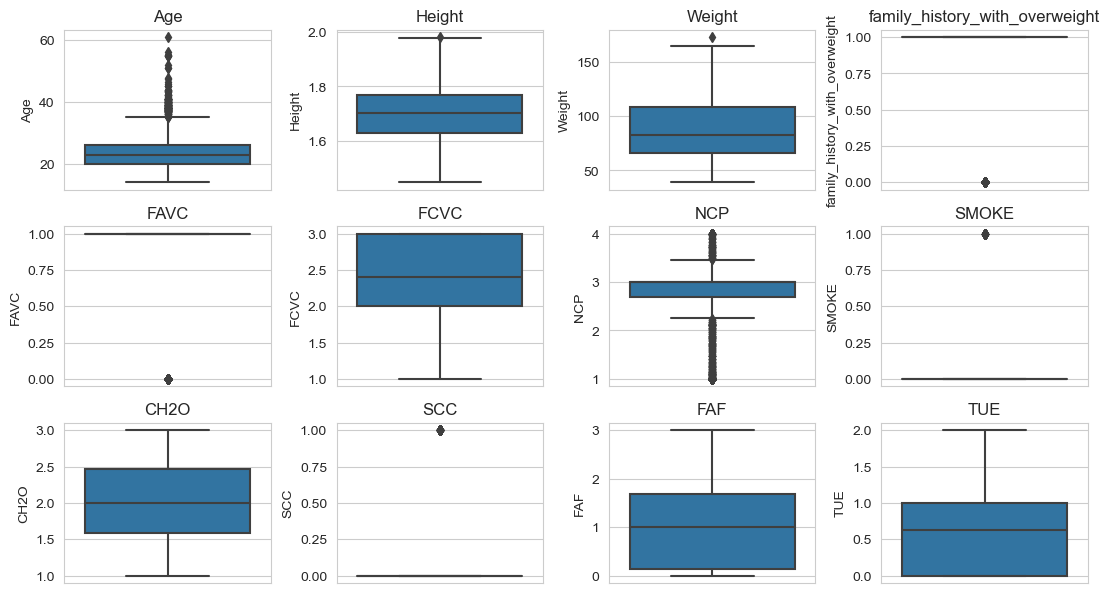

In [23]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(11,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## L'optimisation de mémoire:


Dans cette étape, nous optimisons l'utilisation de la mémoire du dataframe.

La fonction `optimize_memory()` parcourt chaque colonne du dataset et adapte automatiquement son type de données afin de réduire l’espace mémoire utilisé :
- les entiers sont convertis vers le plus petit type possible (`int8`, `int16`, `int32`),
- les nombres décimaux sont convertis en `float32` lorsque cela est possible.

Avant et après l’optimisation, nous affichons les informations du dataframe avec `df.info(memory_usage="deep")` afin de comparer l’utilisation mémoire et mesurer le gain obtenu.

In [24]:
def optimize_memory(df):

    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage BEFORE optimization: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == object:
            df[col] = df[col].astype("category")

        elif col_type != "category":

            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":

                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:

                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2

    print(f"Memory usage AFTER optimization: {end_mem:.2f} MB")
    print(f"Memory reduced by {(100 * (start_mem - end_mem) / start_mem):.1f}%")

    return df

In [25]:
print("Before optimization:")
df.info(memory_usage="deep")
df = optimize_memory(df)

print("\nAfter optimization:")
df.info(memory_usage="deep")

Before optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2087 non-null   category
 1   Age                             2087 non-null   float64 
 2   Height                          2087 non-null   float64 
 3   Weight                          2087 non-null   float64 
 4   family_history_with_overweight  2087 non-null   int64   
 5   FAVC                            2087 non-null   int64   
 6   FCVC                            2087 non-null   float64 
 7   NCP                             2087 non-null   float64 
 8   CAEC                            2087 non-null   category
 9   SMOKE                           2087 non-null   int64   
 10  CH2O                            2087 non-null   float64 
 11  SCC                             2087 non-null   int64   
 12 

In [26]:
print("\nAfter optimization:")
df.info(memory_usage="deep")


After optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2087 non-null   category
 1   Age                             2087 non-null   float32 
 2   Height                          2087 non-null   float32 
 3   Weight                          2087 non-null   float32 
 4   family_history_with_overweight  2087 non-null   int8    
 5   FAVC                            2087 non-null   int8    
 6   FCVC                            2087 non-null   float32 
 7   NCP                             2087 non-null   float32 
 8   CAEC                            2087 non-null   category
 9   SMOKE                           2087 non-null   int8    
 10  CH2O                            2087 non-null   float32 
 11  SCC                             2087 non-null   int8    
 12 

## Exportation du dataset nettoyé :

In [29]:
df.to_csv("data_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Gender                          2087 non-null   category
 1   Age                             2087 non-null   float32 
 2   Height                          2087 non-null   float32 
 3   Weight                          2087 non-null   float32 
 4   family_history_with_overweight  2087 non-null   int8    
 5   FAVC                            2087 non-null   int8    
 6   FCVC                            2087 non-null   float32 
 7   NCP                             2087 non-null   float32 
 8   CAEC                            2087 non-null   category
 9   SMOKE                           2087 non-null   int8    
 10  CH2O                            2087 non-null   float32 
 11  SCC                             2087 non-null   int8    
 12  FAF                 

Après les différentes étapes de nettoyage et de transformation des données, le dataset est sauvegardé dans un nouveau fichier CSV afin de pouvoir être réutilisé dans les étapes suivantes du projet, notamment pour l'entraînement et l'évaluation des modèles de machine learning.

La fonction  `df.info()`  est ensuite utilisée pour afficher un résumé du dataset final, incluant le nombre de lignes, le type des colonnes et l’utilisation de la mémoire. Cela permet de vérifier que les transformations et optimisations ont été correctement appliquées.